# Разработка A/B-тестирования и анализ результатов

Задача от компании, которая разрабатывает развлекательное приложение с функцией «бесконечной» ленты, как, например, в приложениях с короткими видео. В вашем приложении существует две модели монетизации: первая — ежемесячная платная подписка, которая позволяет пользователям смотреть ленту без рекламы, вторая — демонстрация рекламы для пользователей, которые ещё не оформили подписку.

Команда разработчиков рекомендательных систем создала новый алгоритм рекомендаций, который, по их мнению, будет показывать более интересный контент для каждого пользователя. Необходимо рассчитать параметры A/B-теста, который позволит проверить эту гипотезу, и проанализировать его результаты.

## Описание данных
Данные представлены в трех таблицах:

- `sessions_project_history.csv` — таблица с историческими данными по сессиям пользователей на период с 2025-08-15 по 2025-09-23. Путь к файлу: `/datasets/sessions_project_history.csv`.

- `sessions_project_test_part.csv` — таблица с данными за первый день проведения A/B-теста, то есть за 2025-10-14. Путь к файлу: `/datasets/sessions_project_test_part.csv`.

- `sessions_project_test.csv` — таблица с данными за весь период проведения A/B-теста, то есть с 2025-10-14 по 2025-11-02. Путь к файлу: `/datasets/sessions_project_test.csv`.

У этих таблиц почти совпадает структура и содержание колонок, различаются лишь периоды наблюдения.

Поля таблиц `sessions_project_history.csv`, `sessions_project_test.csv`, `sessions_project_test_part.csv`:

- `user_id` — идентификатор пользователя;

- `session_id` — идентификатор сессии в приложении;

- `session_date` — дата сессии;

- `session_start_ts` — дата и время начала сессии;

- `install_date` — дата установки приложения;

- `session_number` — порядковый номер сессии для конкретного пользователя;

- `registration_flag` — является ли пользователь зарегистрированным;

- `page_counter` — количество просмотренных страниц во время сессии;

- `region` — регион пользователя;

- `device` — тип устройства пользователя;

- `test_group` — тестовая группа (в таблице с историческими данными этого столбца нет).


## Что нужно сделать
Задача: рассчитать параметры теста, оценить корректность его проведения и проанализировать результаты эксперимента.

### 1. Работа с историческими данными (EDA)

#### 1.1. Загрузка исторических данных
На первом этапе поработаем с историческими данными приложения:

- Импортируем библиотеку pandas.

- Сохраним в датафрейм `sessions_history` CSV-файл с историческими данными о сессиях пользователей `sessions_project_history.csv`.


In [1]:
import pandas as pd
sessions_history = pd.read_csv('/datasets/sessions_project_history.csv')

sessions_history.head()

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device
0,E302123B7000BFE4,F9AF61A0C2023832,2025-08-15,2025-08-15 17:47:35,2025-08-15,1,0,3,CIS,iPhone
1,2530F72E221829FB,85003A206CBDAC6F,2025-08-15,2025-08-15 16:42:14,2025-08-15,1,0,4,MENA,Android
2,876E020A4FC512F5,3677423E49D72DEE,2025-08-15,2025-08-15 12:30:00,2025-08-15,1,0,4,EU,PC
3,2640B349E1D81584,956B45F5915CA225,2025-08-15,2025-08-15 15:31:31,2025-08-15,1,0,4,CIS,Android
4,94E1CBFAEF1F5EE9,83BF0DA35F9F1F40,2025-08-15,2025-08-15 21:33:53,2025-08-15,1,0,3,CIS,Android


#### 1.2. Знакомство с данными
- Для каждого уникального пользователя `user_id` рассчитаем количество уникальных сессий `session_id`.

- Выведем на экран все данные из таблицы `sessions_history` для одного пользователя с наибольшим количеством сессий. Если таких пользователей несколько, выберем любого из них.

- Изучим таблицу для одного пользователя, чтобы лучше понять логику формирования каждого столбца данных.



In [2]:
sessions_per_user = sessions_history.groupby('user_id', as_index=False)['session_id'].nunique()
sessions_per_user.rename(columns={'session_id': 'sessions_count'}, inplace=True)

sessions_per_user = sessions_per_user.sort_values(by = 'sessions_count', ascending = False).reset_index()
sessions_per_user.head()

max_sessions_count_user = sessions_per_user['user_id'][0]
max_user_info = sessions_history[sessions_history['user_id'] == max_sessions_count_user]
max_user_info

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device
115558,10E0DEFC1ABDBBE0,B8F0423BBFFCF5DC,2025-08-14,2025-08-14 13:57:39,2025-08-14,1,0,4,CIS,Android
191751,10E0DEFC1ABDBBE0,87CA2FA549473837,2025-08-15,2025-08-15 16:42:10,2025-08-14,2,0,3,CIS,Android
239370,10E0DEFC1ABDBBE0,4ADD8011DCDCE318,2025-08-16,2025-08-16 19:53:21,2025-08-14,3,0,3,CIS,Android
274629,10E0DEFC1ABDBBE0,DF0FD0E09BF1F3D7,2025-08-17,2025-08-17 15:03:43,2025-08-14,4,0,1,CIS,Android
302501,10E0DEFC1ABDBBE0,3C221774B4DE6885,2025-08-18,2025-08-18 17:29:14,2025-08-14,5,0,4,CIS,Android
325557,10E0DEFC1ABDBBE0,031BD7A67048105B,2025-08-19,2025-08-19 13:23:55,2025-08-14,6,0,2,CIS,Android
345336,10E0DEFC1ABDBBE0,FF4315CF4AD4B100,2025-08-20,2025-08-20 19:31:54,2025-08-14,7,0,2,CIS,Android
377532,10E0DEFC1ABDBBE0,4045FEA0747203B4,2025-08-22,2025-08-22 17:54:13,2025-08-14,8,0,2,CIS,Android
403538,10E0DEFC1ABDBBE0,344B086C421C7F37,2025-08-24,2025-08-24 14:46:13,2025-08-14,9,0,2,CIS,Android
414743,10E0DEFC1ABDBBE0,054F20BA371E4C9D,2025-08-25,2025-08-25 18:36:41,2025-08-14,10,0,3,CIS,Android


#### 1.3. Анализ числа регистраций
Одна из важнейших метрик продукта — число зарегистрированных пользователей. Используя исторические данные, визуализируем, как менялось число регистраций в приложении за время его существования.

- Агрегируем исторические данные и рассчитаем число уникальных пользователей и число зарегистрированных пользователей для каждого дня наблюдения. 

- Построим линейные графики общего числа пользователей и общего числа зарегистрированных пользователей по дням.

- Построим отдельный линейный график доли зарегистрированных пользователей от всех пользователей по дням.

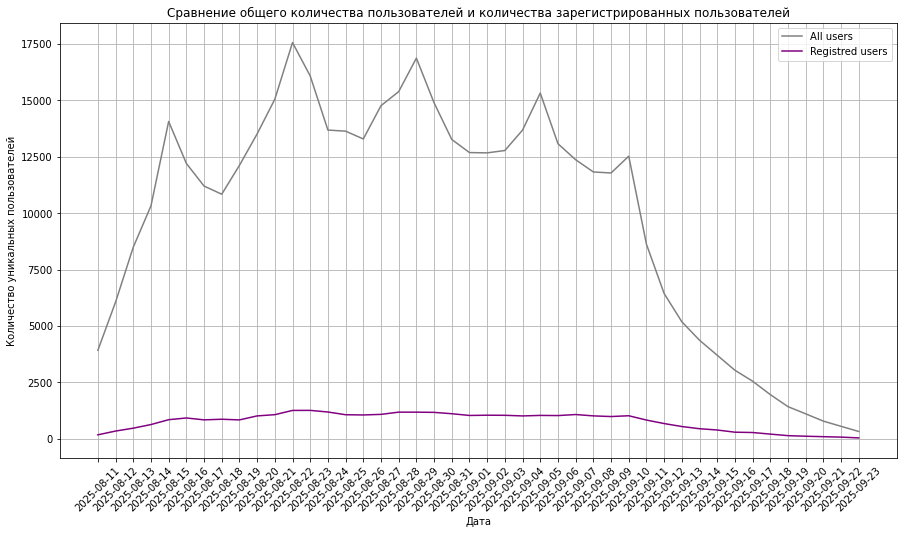

In [3]:
import matplotlib.pyplot as plt

sessions_history_reg = sessions_history[sessions_history['registration_flag'] == 1]

users_per_day = sessions_history.groupby('session_date',as_index=False)['user_id'].nunique()
reg_users_per_day = sessions_history_reg.groupby('session_date',as_index=False)['user_id'].nunique()


x = users_per_day.session_date.unique()
y_all = users_per_day.user_id
y_reg = reg_users_per_day.user_id

plt.figure(figsize=(15, 8))
plt.plot(x, y_all, label ='All users', color = 'grey')
plt.plot(x, y_reg,label ='Registred users', color = 'purple')

plt.xlabel("Дата")
plt.ylabel("Количество уникальных пользователей")
plt.xticks(rotation=45)
plt.legend()
plt.grid()
plt.title('Сравнение общего количества пользователей и количества зарегистрированных пользователей')
plt.show()


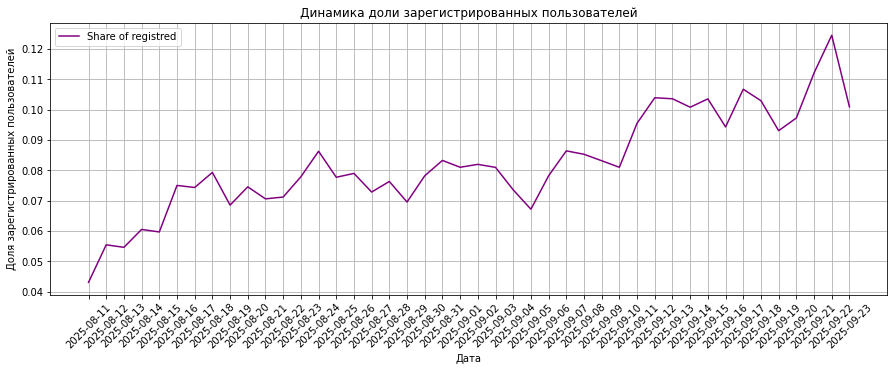

In [4]:
users_per_day_with_reg = sessions_history.groupby('session_date',as_index=False).agg({'user_id':'nunique','registration_flag':'sum'})
    
users_per_day_with_reg['share_of_reg'] = users_per_day_with_reg['registration_flag'] / users_per_day_with_reg['user_id']
x = users_per_day_with_reg.session_date.unique()
y = users_per_day_with_reg['share_of_reg']

plt.figure(figsize=(15, 5))
plt.plot(x, y, label ='Share of registred', color = 'purple')


plt.xlabel("Дата")
plt.ylabel("Доля зарегистрированных пользователей")
plt.xticks(rotation=45)
plt.legend()
plt.grid()
plt.title('Динамика доли зарегистрированных пользователей')
plt.show()


На графике с долей зарегистрированных пользователей виден постепенный прирост от 4% в начале августа до 10-12% в конце сентября. Если сравнить эту динамику с графиком с абсолютным количеством пользователей, увидим, что общее количество пользователей сервиса росло примерно до 20 августа. Далее с учетом ярко выраженной недельной сезонности начинается постепенный спад, значительно ускоряющийся с 7 сентября. При этом абсолютное количество зарегистрированных пользователей более стабильно. Можно предположить, что с начала августа в приложение пришел большой поток новых клиентов, часть из них зарегистрировались и стали постоянными, а основная масса отсеялась и стала заходить реже. Т.е. доля зарегистрированных пользователей до 20-х чисел августа увеличивалась за счет новых регистраций, а после - за счет снижения количества незарегистрированных пользователей. Подтверждением этому является график в динамикой абсолютного количества зарегистрированных пользователей.

#### 1.4. Анализ числа просмотренных страниц
Другая важная метрика продукта — число просмотренных страниц в приложении. Чем больше страниц просмотрено, тем сильнее пользователь увлечён контентом, а значит, выше шансы, что он зарегистрируется и оплатит подписку.

- Найдем количество сессий для каждого значения количества просмотренных страниц. Например: одну страницу просмотрели в 29 160 сессиях, две страницы — в 105 536 сессиях и так далее.

- Построим столбчатую диаграмму, где по оси X будет число просмотренных страниц, по оси Y — количество сессий.

- На диаграмме должны быть заголовок, подписанные оси X и Y.

In [5]:
session_per_pages_count = sessions_history.groupby('page_counter')['session_id'].count()
session_per_pages_count

page_counter
1     29160
2    105536
3    166690
4    105569
5     26288
6      2589
7        92
Name: session_id, dtype: int64

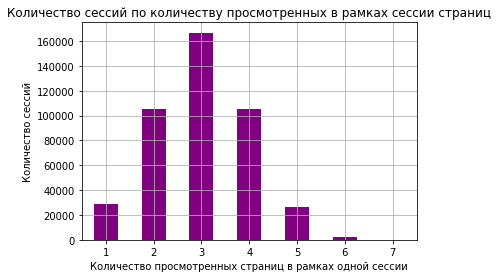

In [6]:
session_per_pages_count.plot(kind = 'bar', rot = 360, grid = True, color = 'purple')

plt.title('Количество сессий по количеству просмотренных в рамках сессии страниц')
plt.xlabel('Количество просмотренных страниц в рамках одной сессии')
plt.ylabel('Количество сессий')

plt.show()

Для количества частоты встречаемости определенного количества страниц в рамках одной сессии видим распредление близкое к нормальному: чаще всего в рамках одной сессии просматривают 3 страницы, большая часть сессий содержит от 2 до 4 страниц.

#### 1.5. Доля пользователей, просмотревших более четырёх страниц
Продуктовая команда продукта считает, что сессии, в рамках которых пользователь просмотрел 4 и более страниц, говорят об удовлетворённости контентом и алгоритмами рекомендаций. Этот показатель является важной прокси-метрикой для продукта.

- В датафрейме `sessions_history` создадим дополнительный столбец `good_session`. В него войдёт значение `1`, если за одну сессию было просмотрено 4 и более страниц, и значение `0`, если было просмотрено меньше.

- Построим график со средним значением доли успешных сессий от всех сессий по дням за весь период наблюдения.

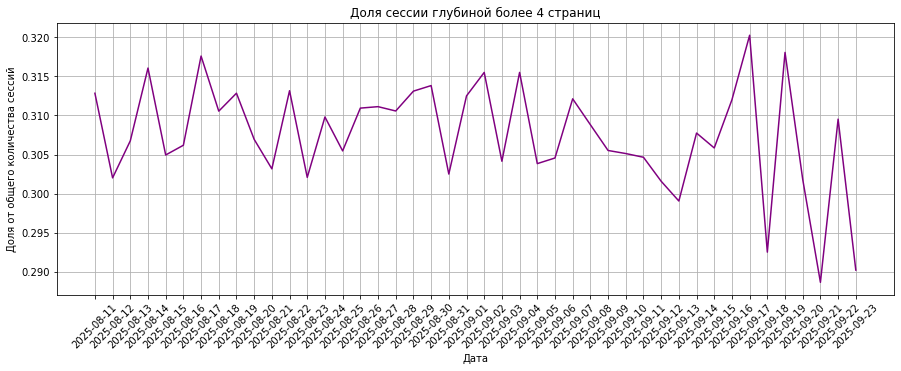

In [7]:
sessions_history['good_session'] = pd.cut(sessions_history['page_counter'], bins = [0,3,10], labels = [0,1])
sessions_history['good_session'] = sessions_history['good_session'].astype('int64')

good_sessions_share = sessions_history.groupby('session_date',as_index=False).agg({'session_id':'count', 'good_session':'sum'})

good_sessions_share['share'] = good_sessions_share['good_session'] / good_sessions_share['session_id']

x = good_sessions_share.session_date.unique()
y = good_sessions_share['share']

plt.figure(figsize=(15, 5))
plt.plot(x, y, label ='Share of sessions bigger than 4 pages', color = 'purple')


plt.xlabel("Дата")
plt.ylabel("Доля от общего количества сессий")
plt.xticks(rotation=45)
plt.grid()
plt.title('Доля сессии глубиной более 4 страниц')
plt.show()


Доля сессий с глубиной 4 и более страницы от общего количества сессий в приложении колеблется от 29% до 32% 

### 2. Подготовка к тесту

#### 2.1 Формулировка нулевой и альтернативной гипотез

Наиболее подходящая метрика для оценки заинтересованности пользователей контентом приложения - доля сессий глубиной 4 и более страницы. Использование долевой метрики позволит снизить влияние выбросов в данных о количестве страниц в рамках одной сессии. 

H0: Доля сессий с глубиной 4 и более страниц в группах A и B не отличается, т.е. μA = μB

H1 (односторонняя): Доля сессий с глубиной 4 и более страниц в группе B будет выше, чем в группе A, т.е. μA < μB





#### 2.2. Расчёт размера выборки
Рассчитаем необходимое для эксперимента количество пользователей.

Для этого установим следующие параметры:

- Уровень значимости — 0.05.

- Вероятность ошибки второго рода — 0.2.

- Минимальный детектируемый эффект, или MDE, — 3%.

In [8]:
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize

# Задаём параметры
alpha = 0.05  # Уровень значимости
beta = 0.2  # Ошибка второго рода, часто 1 - мощность
power = 1 - beta  # Мощность теста
p1 = 0.3 # Базовый уровень доли
mde = 0.03 # Минимальный детектируемый эффект
effect_size = proportion_effectsize(p1, p1 + mde)

# Инициализируем класс NormalIndPower
power_analysis = NormalIndPower()

# Рассчитываем размер выборки
sample_size = power_analysis.solve_power(
    effect_size = effect_size,
    power = power,
    alpha = alpha,
    ratio = 1 # Равномерное распределение выборок
)

print(f"Необходимый размер выборки для каждой группы: {int(sample_size)}")

Необходимый размер выборки для каждой группы: 3761


#### 2.3. Расчёт длительности A/B-теста

- Рассчитаем среднее количество уникальных пользователей приложения в день.

- Определим длительность теста исходя из рассчитанного значения размера выборок и среднего дневного трафика приложения.

In [9]:
from math import ceil

# Среднее количество пользователей приложения в день по историческим данным
avg_daily_users = round(sessions_history['session_id'].count() / sessions_history['session_date'].nunique())

# Рассчитываем длительность теста в днях как отношение размера выборки к среднему числу пользователей
test_duration = ceil((sample_size * 2) / avg_daily_users)

print(f"Рассчитанная длительность A/B-теста при текущем уровене трафика в {avg_daily_users} пользователей в день составит {test_duration} дней")

Рассчитанная длительность A/B-теста при текущем уровене трафика в 9907 пользователей в день составит 1 дней


### 3. Мониторинг А/В-теста

#### 3.1. Проверка распределения пользователей

A/B-тест успешно запущен, и уже доступны данные за первые три дня. На этом этапе нужно убедиться, что всё идёт хорошо: пользователи разделены правильным образом, а интересующие вас метрики корректно считаются.

-Сохраним в датафрейм `sessions_test_part` CSV-файл с историческими данными о сессиях пользователей `sessions_project_test_part.csv`.

- Рассчитаем количество уникальных пользователей в каждой из экспериментальных групп для одного дня наблюдения.

- Рассчитаем процентную разницу в количестве пользователей в группах A и B. 

Для расчёта процентной разницы воспользуйемся формулой:
$$P = 100 \cdot  \frac{|A − B|}{A}$$

In [10]:
sessions_test_part = pd.read_csv('/datasets/sessions_project_test_part.csv')

grp = sessions_test_part.groupby(['session_date','test_group'], as_index=False).agg({'user_id':'nunique'})
count_a = grp[grp['test_group'] == 'A']['user_id'].max()
count_b = grp[grp['test_group'] == 'B']['user_id'].max()

difference = round(100 * ((count_a - count_b) / count_a),2)

display(f'Процентная разница в количестве пользователей в группах A и B составляет {difference}%',f'В группе A {count_a} пользователей, в группе B {count_b} пользователей')

'Процентная разница в количестве пользователей в группах A и B составляет 0.74%'

'В группе A 1477 пользователей, в группе B 1466 пользователей'

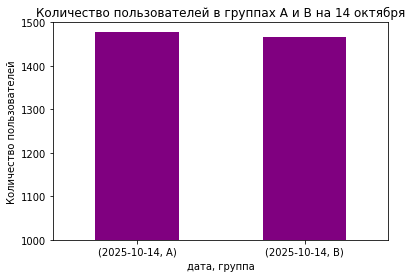

In [11]:
grp1 = sessions_test_part.groupby(['session_date','test_group']).agg({'user_id':'nunique'})

ax = grp1.plot(kind = 'bar', rot = 360, legend = False, color = 'purple')

plt.title('Количество пользователей в группах A и B на 14 октября')
plt.ylabel('Количество пользователей')
plt.xlabel('дата, группа')
ax.set_ylim([1000, 1500])

plt.show()

#### 3.2. Проверка пересечений пользователей
Помимо проверки равенства количества пользователей в группах, полезно убедиться в том, что группы независимы. Для этого нужно убедиться, что никто из пользователей случайно не попал в обе группы одновременно.

- Рассчитаем количество пользователей, которые встречаются одновременно в группах A и B, или убедимся, что таких нет.

In [12]:
gr_a = sessions_test_part[sessions_test_part['test_group'] == 'A']['user_id']
gr_b = sessions_test_part[sessions_test_part['test_group'] == 'B']['user_id']

intersection = list(set(gr_a) & set(gr_b))

if len(intersection) > 0:
    display(f'Группы A и B имеют {len(intersection)} общих значений: {intersection}')
else:
    display(f'Группы A и B не имеют пересечений')

'Группы A и B не имеют пересечений'

#### 3.3. Равномерность разделения пользователей по устройствам
Полезно также убедиться в том, что пользователи равномерно распределены по всем доступным категориальным переменным — типам устройств и регионам.

Построим две диаграммы:

- доля каждого типа устройства для пользователей из группы A,

- доля каждого типа устройства для пользователей из группы B.


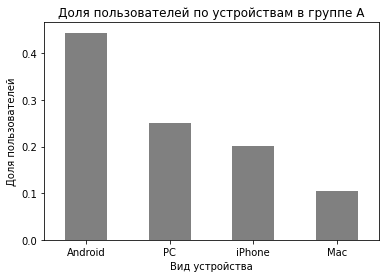

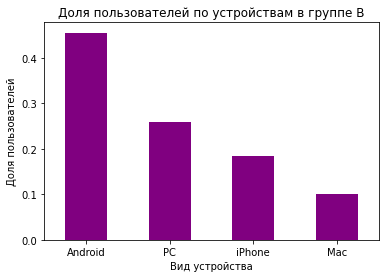

'Распределение пользователей по устройствам в группах A и B совпадает'

In [13]:
from matplotlib import pyplot as plt

grp_by_device_a = sessions_test_part[sessions_test_part['test_group'] == 'A'].groupby('device').agg({'user_id':'nunique'}).sort_values(by = 'user_id', ascending = False)
grp_by_device_a['share'] = grp_by_device_a['user_id'] / sessions_test_part[sessions_test_part['test_group'] == 'A']['user_id'].nunique()

grp_by_device_a['share'].plot(kind = 'bar', rot = 360, legend = False, color = 'grey')

plt.title('Доля пользователей по устройствам в группе A')
plt.ylabel('Доля пользователей')
plt.xlabel('Вид устройства')


plt.show()

grp_by_device_b = sessions_test_part[sessions_test_part['test_group'] == 'B'].groupby('device').agg({'user_id':'nunique'}).sort_values(by = 'user_id', ascending = False)
grp_by_device_b['share'] = grp_by_device_b['user_id'] / sessions_test_part[sessions_test_part['test_group'] == 'B']['user_id'].nunique()
grp_by_device_b['share'].plot(kind = 'bar', rot = 360, legend = False, color = 'purple')

plt.title('Доля пользователей по устройствам в группе B')
plt.ylabel('Доля пользователей')
plt.xlabel('Вид устройства')


plt.show()
display('Распределение пользователей по устройствам в группах A и B совпадает')

#### 3.4. Равномерность распределения пользователей по регионам
Теперь убедимся, что пользователи равномерно распределены по регионам.

Построим две диаграммы:

- доля каждого региона для пользователей из группы A,

- доля каждого региона для пользователей из группы B.

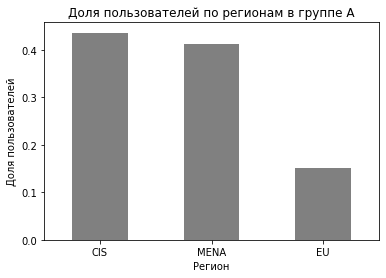

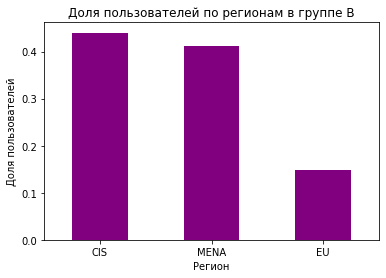

'Между распределениями пользователей по регионам в группах A и B есть отличия'

In [14]:
grp_by_region_a = sessions_test_part[sessions_test_part['test_group'] == 'A'].groupby('region').agg({'user_id':'nunique'}).sort_values(by = 'user_id', ascending = False)
grp_by_region_a['share'] = grp_by_region_a['user_id'] / sessions_test_part[sessions_test_part['test_group'] == 'A']['user_id'].nunique()

grp_by_region_a['share'].plot(kind = 'bar', rot = 360, legend = False, color = 'grey')

plt.title('Доля пользователей по регионам в группе A')
plt.ylabel('Доля пользователей')
plt.xlabel('Регион')


plt.show()

grp_by_region_b = sessions_test_part[sessions_test_part['test_group'] == 'B'].groupby('region').agg({'user_id':'nunique'}).sort_values(by = 'user_id', ascending = False)
grp_by_region_b['share'] = grp_by_region_b['user_id'] / sessions_test_part[sessions_test_part['test_group'] == 'B']['user_id'].nunique()

grp_by_region_b['share'].plot(kind = 'bar', rot = 360, legend = False, color = 'purple')

plt.title('Доля пользователей по регионам в группе B')
plt.ylabel('Доля пользователей')
plt.xlabel('Регион')


plt.show()

display('Между распределениями пользователей по регионам в группах A и B есть отличия')


#### 3.5. Вывод после проверки A/B-теста


Проведен мониторинг A/B-теста по результатам первого дня - 14 октября:
* В группе A 1477 пользователей, в группе B 1466 пользователей. Процентная разница в количестве пользователей в группах A и B составляет 0.74% - такое небольшое различие не окажет значимого влияния на результат тестирования.
* Пересечений между выборками не обнаружено, значит выборки являются независимыми - это важно для применения статистических тестов.
* Пользователи в контрольной и тестовой группах одинаково распределены по устройствам. Распределение пользователей по регионам так же очень близко: в группе A 44% пользователей из региона CIS, 41% - MENA, 15% - EU. В группе B 44% из CIS, 41% - MENA, 15% - EU. 

В целом A/B-тест проходит корректно.


### 4. Проверка результатов A/B-теста

A/B-тест завершён, и у нас есть результаты за все дни проведения эксперимента. Необходимо убедиться в корректности теста и верно интерпретировать результаты.

#### 4.1. Получение результатов теста и подсчёт основной метрики

- Сохраним в датафрейм `sessions_test` CSV-файл с историческими данными о сессиях пользователей `sessions_project_test.csv`.

- В датафрейме `sessions_test` создадим дополнительный столбец `good_session`. В него войдёт значение `1`, если за одну сессию было просмотрено 4 и более страниц, и значение `0`, если просмотрено меньше.

In [15]:
sessions_test = pd.read_csv('/datasets/sessions_project_test.csv')
sessions_test['good_session'] = pd.cut(sessions_test['page_counter'], bins = [0,3,15], labels = [0,1])
sessions_test['good_session'] = sessions_test['good_session'].astype('int64')

by_groups = sessions_test.groupby('test_group', as_index = False).agg({'user_id':'nunique','good_session':'sum'})

by_groups

,test_group,user_id,good_session
0,A,15163,15248
1,B,15416,16059


#### 4.2. Проверка корректности результатов теста

Прежде чем приступать к анализу ключевых продуктовых метрик, необходимо убедиться, что тест проведён корректно и мы будем сравнивать две сопоставимые группы.


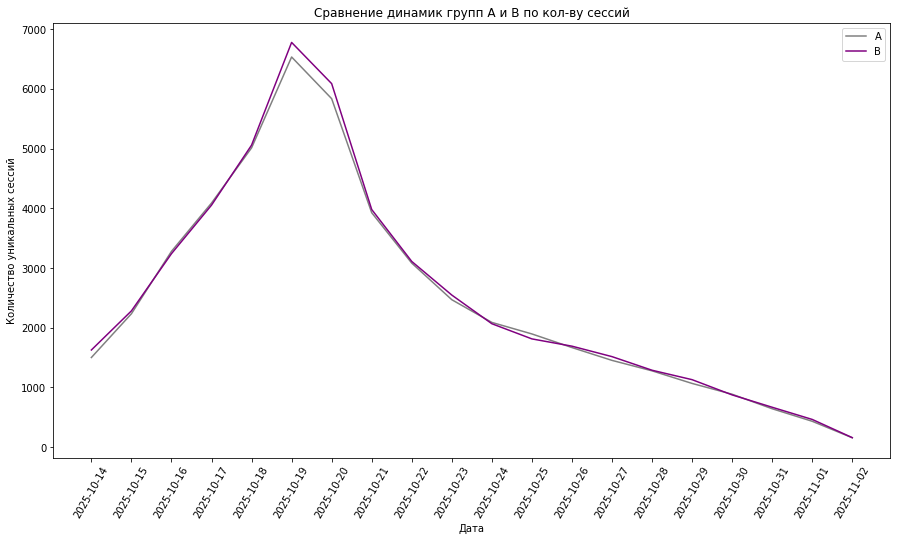

In [16]:
res_grp = sessions_test.groupby(['test_group', 'session_date'], as_index=False).agg({'session_id': 'nunique'})

x = res_grp.session_date.unique()
y_a = res_grp[res_grp.test_group=='A'].session_id
y_b = res_grp[res_grp.test_group=='B'].session_id
plt.figure(figsize=(15, 8))
plt.plot(x, y_a, label ='A', color = 'grey')
plt.plot(x, y_b,label ='B', color = 'purple')

plt.xlabel("Дата")
plt.ylabel("Количество уникальных сессий")
plt.legend()
plt.title('Сравнение динамик групп A и B по кол-ву сессий')
plt.xticks(rotation=60)
plt.show()

In [17]:
from scipy.stats import ttest_ind

alpha = 0.05
count_result = ttest_ind(y_a, y_b, alternative = 'two-sided')

display(f'p-value = {count_result.pvalue}')

if count_result.pvalue < alpha:
    display('В среднем количестве сессий в день в групах A и B наблюдается значимое различие')
else:
    display('Средние количества сессий в день в группах A и B не различаются')


'p-value = 0.938219304859116'

'Средние количества сессий в день в группах A и B не различаются'

#### 4.3. Сравнение доли успешных сессий

Когда мы убедились, что количество сессий в обеих выборках не различалось, можно переходить к анализу ключевой метрики — доли успешных сессий.

Используем созданный на первом шаге задания столбец `good_session` и рассчитаем долю успешных сессий для выборок A и B, а также разницу в этом показателе.

In [18]:
share_of_good_a = round(sessions_test[sessions_test['test_group'] == 'A']['good_session'].sum() / sessions_test[sessions_test['test_group'] == 'A']['session_id'].count(),2)
share_of_good_b = round(sessions_test[sessions_test['test_group'] == 'B']['good_session'].sum() / sessions_test[sessions_test['test_group'] == 'B']['session_id'].count(),2)
diff = round(100 * (share_of_good_b - share_of_good_a))


display(f'Для группы A доля успешных сессий составляет {share_of_good_a}, для группы B доля успешных сессий составляет {share_of_good_b}')
display(f'Разница в показателе доли успешных сессий между группами составляет {diff} процентный пункт')


'Для группы A доля успешных сессий составляет 0.31, для группы B доля успешных сессий составляет 0.32'

'Разница в показателе доли успешных сессий между группами составляет 1 процентный пункт'

#### 4.4. Насколько статистически значимо изменение ключевой метрики

На предыдущем шаге мы убедились, что количество успешных сессий в тестовой выборке примерно на 1.1% выше, чем в контрольной, но делать выводы только на основе этого значения будет некорректно. Для принятия решения всегда необходимо отвечать на вопрос: является ли это изменение статистически значимым.

- Используя статистический тест, рассчитем, является ли изменение в метрике доли успешных сессий статистически значимым.

- Выведем на экран полученное значение p-value и свои выводы о статистической значимости.

In [19]:
from statsmodels.stats.proportion import proportions_ztest #используем Z-тест т.к. выбрана долевая метрика

m_a = sessions_test[sessions_test['test_group'] == 'A']['good_session'].sum()
m_b = sessions_test[sessions_test['test_group'] == 'B']['good_session'].sum()

n_a = sessions_test[sessions_test['test_group'] == 'A']['session_id'].count()
n_b = sessions_test[sessions_test['test_group'] == 'B']['session_id'].count()

stat_ztest, p_value_ztest = proportions_ztest([m_a,m_b],[n_a,n_b], alternative = 'smaller')

display(f'p-value = {round(p_value_ztest,6)}')

if p_value_ztest > alpha:
    display('Не получилось отвергнуть нулевую гипотезу')
else:
    display('Отвергаем нулевую гипотезу')



'p-value = 0.000157'

'Отвергаем нулевую гипотезу'

#### 4.5. Вывод по результатам A/B-эксперимента



Проведен A/B-тест с вводными:
* Размер контрольной группы 15163, размер экспериментальной группы 15416. 
* Период проведения: с 2025-10-14 по 2025-11-02, всего 20 дней.
* Выбран стандартный уровень статистической значимости - 5%.
* Основная метрика теста - доля сессий с глубиной 4 и более страниц. Базовый уровень метрики - 30%.
* Для определения значимости различий результатов в экспериментальной и контрольной группах выбран Z-тест, т.к. основная метрика является долевой.
* Экспериментальное воздействие - новый алгоритм рекомендаций контента.

Внедрение нового алгоритма рекомендаций для тестовой группы привело к росту доли сессий с глубиной 4 и более страниц на 1 процентный пункт по сравнению с контрольной группой.

Значение p-value для оценки статистичесткой значимости выявленного эффекта составило 0.000157, что значительно меньше заданного уровня статистической значимости.

Рекомендую постепенно масштабировать новый алгоритм рекомендаций контента.
